#### Group-12 MLC Project Codes

Importing The Required Libraries

In [1]:
import os
import warnings
import logging
from absl import logging as absl_logging
import tensorflow as tf
import cv2
import numpy as np
import pytesseract
from flask import Flask, render_template, request
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

- Loads the MNIST handwritten digit dataset and preprocesses the images for training.
- Builds and trains a Convolutional Neural Network (CNN) model for digit recognition.
- Saves the trained model as Models/Digit_Model.keras for future predictions.

In [2]:
# Must be set BEFORE tensorflow import
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
os.environ['CUDA_VISIBLE_DEVICES']='-1'

warnings.filterwarnings('ignore')

# Silence tensorflow logs
logging.disable(logging.WARNING)

# Silence absl logs
absl_logging.set_verbosity('error')

# Disable tensorflow logger
tf.get_logger().setLevel('ERROR')

# Loading MNIST dataset
(trainImages,trainLabels),(testImages,testLabels)=tf.keras.datasets.mnist.load_data()

# Normalizing pixel values
trainImages=trainImages.astype("float32")/255.0
testImages=testImages.astype("float32")/255.0

# Reshaping for CNN
trainImages=trainImages.reshape(-1,28,28,1)
testImages=testImages.reshape(-1,28,28,1)

# LOADING CUSTOM HANDWRITTEN DATA
customImages=[]
customLabels=[]
customDatasetPath="Static/CustomData"
print("Loading Custom Dataset...")
for digitLabel in range(10):
    folderPath=os.path.join(customDatasetPath,str(digitLabel))
    if not os.path.exists(folderPath):
        continue
    for imageName in os.listdir(folderPath):
        imagePath=os.path.join(folderPath,imageName)
        image=cv2.imread(imagePath,cv2.IMREAD_GRAYSCALE)
        if image is None:
            continue

        # Binary threshold
        _,image=cv2.threshold(image,120,255,cv2.THRESH_BINARY_INV)

        # Preserve aspect ratio
        imageHeight,imageWidth=image.shape

        if imageHeight>imageWidth:
            newHeight=20
            newWidth=int(imageWidth*20/imageHeight)
        else:
            newWidth=20
            newHeight=int(
                imageHeight*20/imageWidth
            )
        image=cv2.resize(image,(newWidth,newHeight))

        # Create black canvas
        canvas=np.zeros((28,28),dtype=np.uint8)
        startX=(28-newWidth)//2
        startY=(28-newHeight)//2
        canvas[startY:startY+newHeight,startX:startX+newWidth]=image

        # Normalize
        canvas=canvas.astype("float32")/255.0

        # Reshape
        canvas=canvas.reshape(28,28,1)

        customImages.append(canvas)
        customLabels.append(digitLabel)
print(
    f"Custom Images Loaded : "
    f"{len(customImages)}"
)

# COMBINING DATASETS

if len(customImages)>0:
    customImages=np.array(customImages)
    customLabels=np.array(customLabels)
    trainImages=np.concatenate((trainImages,customImages),axis=0)
    trainLabels=np.concatenate((trainLabels,customLabels),axis=0)

print(
    "Total Training Images :",
    len(trainImages)
)

# DATA AUGMENTATION
dataAugmentation=tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomTranslation(height_factor=0.08,width_factor=0.08)
])

# CNN MODEL
digitModel=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    dataAugmentation,
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10,activation='softmax')
])

# COMPILING MODEL

digitModel.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAINING Model
print("\nModel Training...\n")

trainingHistory=digitModel.fit(
    trainImages,
    trainLabels,
    epochs=15,
    batch_size=32,
    validation_data=(testImages,testLabels)
)

# SAVING MODEL
os.makedirs("Model",exist_ok=True)
digitModel.save("Model/Digit_Model.keras")
print("\nModel Saved Successfully.")

Loading Custom Dataset...
Custom Images Loaded : 2
Total Training Images : 60002

Model Training...

Epoch 1/15
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9271 - loss: 0.2368 - val_accuracy: 0.9604 - val_loss: 0.1328
Epoch 2/15
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9668 - loss: 0.1141 - val_accuracy: 0.9842 - val_loss: 0.0492
Epoch 3/15
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9734 - loss: 0.0926 - val_accuracy: 0.9874 - val_loss: 0.0392
Epoch 4/15
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9763 - loss: 0.0835 - val_accuracy: 0.9841 - val_loss: 0.0603
Epoch 5/15
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9781 - loss: 0.0763 - val_accuracy: 0.9802 - val_loss: 0.0785
Epoch 6/15
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9795 - loss: 0.0716 - val_accuracy: 0.9863 - val_loss: 0.0506
Epoch 7/15
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9814 - loss: 0.0659 - val_accuracy: 0

Defining the OCR Path For Scanning

In [3]:
# Tesseract OCR Path
pytesseract.pytesseract.tesseract_cmd=(
    r"D:\VS Code Files\B.Tech Journey\3rd Year\6th Semester\MLC2_2341019456\MLC Project\Tesseract OCR\tesseract.exe"
)

Loading The Trained Model

In [4]:
# Loading already trained model
loadedModel=tf.keras.models.load_model("Model/Digit_Model.keras")
print("Model Loaded Successfully")

Model Loaded Successfully


Performing The OCR Scan

In [5]:
# OCR Scanner
def performOCR(imagePath):
    image=cv2.imread(imagePath)
    if image is None:
        return None
    grayImage=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    blurredImage=cv2.GaussianBlur(grayImage,(3,3),0)
    _,thresholdImage=cv2.threshold(blurredImage,120,255,cv2.THRESH_BINARY_INV)
    extractedText=pytesseract.image_to_string(thresholdImage,config='--psm 7')
    extractedText=extractedText.strip()
    extractedText=extractedText.replace(" ","")
    return extractedText

Digit Segmentation (Multiple Digits)

- Processes the uploaded image using OpenCV techniques like thresholding and contour detection.
- Identifies and extracts multiple handwritten digits from a single image.
- Resizes and formats each detected digit into a standard 28×28 format for prediction.

In [6]:

# Function to auto-correct rotated images
def fixRotation(imageData):
    points=np.column_stack(np.where(imageData > 0))

    # No foreground found
    if len(points)==0:
        return imageData
    angle=cv2.minAreaRect(points)[-1]

    # Correct OpenCV angle format
    if angle < -45:
        angle=-(90 + angle)
    else:
        angle=-angle

    # IMPORTANT SAFETY CHECK
    # Ignore tiny rotations
    # Prevents distortion of digits like 1
    if abs(angle)<8:
        return imageData
    imageHeight,imageWidth=imageData.shape[:2]
    imageCenter=(imageWidth//2,imageHeight//2)
    rotationMatrix=cv2.getRotationMatrix2D(imageCenter,angle,1.0)
    rotatedImage=cv2.warpAffine(imageData,rotationMatrix,(imageWidth,imageHeight),flags=cv2.INTER_CUBIC,borderMode=cv2.BORDER_REPLICATE)
    return rotatedImage

Digit Preparation

In [7]:
# PREPARE DIGIT

def prepareDigit(digitImage):

    # Finding exact digit area
    coordinates=cv2.findNonZero(digitImage)

    if coordinates is None:
        return np.zeros((28,28),dtype="float32")

    xPos,yPos,boxWidth,boxHeight=cv2.boundingRect(
        coordinates
    )

    # Cropping extra black area
    croppedDigit=digitImage[
        yPos:yPos+boxHeight,
        xPos:xPos+boxWidth
    ]

    h,w=croppedDigit.shape

    # Preserve aspect ratio
    if h>w:

        newH=20

        newW=max(
            1,
            int(w*20/h)
        )

    else:

        newW=20

        newH=max(
            1,
            int(h*20/w)
        )

    # Resize properly
    resizedDigit=cv2.resize(
        croppedDigit,
        (newW,newH)
    )

    # Creating black canvas
    canvas=np.zeros(
        (28,28),
        dtype=np.uint8
    )

    # Centering digit
    startX=(28-newW)//2
    startY=(28-newH)//2

    canvas[
        startY:startY+newH,
        startX:startX+newW
    ]=resizedDigit

    # Smooth edges slightly
    canvas=cv2.GaussianBlur(
        canvas,
        (3,3),
        0
    )

    # Normalize
    canvas=canvas.astype(
        "float32"
    )/255.0

    return canvas

Function For Extracting The Digits

In [8]:
# EXTRACT DIGITS
def extractDigits(imagePath):
    image=cv2.imread(imagePath,cv2.IMREAD_GRAYSCALE)
    if image is None:
        print("Image Not Found")
        return []

    # Blur
    blurredImage=cv2.GaussianBlur(image,(5,5),0)

    # Binary threshold
    _,thresholdImage=cv2.threshold(blurredImage,120,255,cv2.THRESH_BINARY_INV)

    # Morphological cleanup
    kernel=np.ones((3,3),np.uint8)
    thresholdImage=cv2.morphologyEx(thresholdImage,cv2.MORPH_CLOSE,kernel)

    # Finding contours
    contoursFound,_=cv2.findContours(thresholdImage,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    digitImages=[]
    xPositions=[]

    # Minimum contour area
    minimumArea=80
    for singleContour in contoursFound:
        contourArea=cv2.contourArea(singleContour)
        if contourArea<minimumArea:
            continue
        xPos,yPos,boxWidth,boxHeight=(cv2.boundingRect(singleContour))

        # Ignore tiny noises
        if boxWidth<5 or boxHeight<15:
            continue

        # Ignore giant noise
        if boxWidth>image.shape[1]*0.9:
            continue
        extractedDigit=thresholdImage[yPos:yPos+boxHeight,xPos:xPos+boxWidth]

        # Padding
        extractedDigit=cv2.copyMakeBorder(extractedDigit,8,8,8,8,cv2.BORDER_CONSTANT,value=0)
        processedDigit=prepareDigit(extractedDigit)
        digitImages.append(processedDigit)
        xPositions.append(xPos)

    # Sorting left-to-right
    orderedPairs=sorted(zip(xPositions,digitImages),key=lambda item:item[0])
    orderedDigits=[digit for _,digit in orderedPairs]
    return orderedDigits

Check For Roman Numeral

In [9]:
# Checking Roman Numeral
def isRomanNumeral(text):
    allowedCharacters=set(
        "IVXLCDMivxlcdm"
    )
    if len(text)==0:
        return False
    return all(
        character in allowedCharacters
        for character in text
    )

Convert To Roman Numerals

In [10]:
# Roman Numeral To Integer
def romanToInteger(romanText):
    romanText=romanText.upper()
    romanDictionary={
        'I':1,
        'V':5,
        'X':10,
        'L':50,
        'C':100,
        'D':500,
        'M':1000
    }
    totalValue=0
    previousValue=0
    for character in reversed(romanText):
        currentValue=romanDictionary.get(character,0)
        if currentValue<previousValue:
            totalValue-=currentValue
        else:
            totalValue+=currentValue
        previousValue=currentValue
    return totalValue

Prediction Script

- Loads the trained deep learning model and predicts the handwritten digits.
- Uses segmented digit images to detect multiple numbers in sequence.
- Displays the final recognized number as output.

In [11]:
# MAIN PREDICTION FUNCTION
def predictDigits(imagePath):
    
    # OCR DETECTION
    extractedText=performOCR(imagePath)
    
    # print("\nOCR Detected :",extractedText)

    # ROMAN NUMERAL CHECK
    if (extractedText is not None and isRomanNumeral(extractedText)):
        convertedNumber=romanToInteger(extractedText)
        print(
            f"\nRoman Numeral "
            f"{extractedText} "
            f"= {convertedNumber}"
        )
        return convertedNumber

    # DIGIT EXTRACTION
    digitList=extractDigits(imagePath)
    
    if len(digitList)==0:
        print("No Digits Were Found")
        return None
    finalResult=[]
    for indexNumber,singleDigit in enumerate(digitList):
        singleDigit=singleDigit.reshape(1,28,28,1)
        predictionResult=loadedModel.predict(singleDigit,verbose=0)
        detectedNumber=np.argmax(predictionResult)
        confidenceScore=(np.max(predictionResult)*100)
        print(
            f"Digit {indexNumber+1} "
            f"Detected As "
            f"{detectedNumber} "
            f"With "
            f"{confidenceScore:.2f}% "
            f"Confidence"
        )
        finalResult.append(str(detectedNumber))
    joinedNumber="".join(finalResult)
    print("\nFinal Detected Number :",joinedNumber)
    return joinedNumber

Getting Valuable From The Model

In [12]:
## Sample Test
enteredImage=input("\nEnter Image Path: ")

## Sample Output
print("The Prediction: ",predictDigits(enteredImage),'\n')

## Multiple Checks
while True:
    enteredImage=input("\nEnter Image Path: ")
    if enteredImage.lower()=="exit":
        print("Program Stopped.")
        break
    print("The Prediction : ",predictDigits(enteredImage),'\n')

Digit 1 Detected As 3 With 100.00% Confidence
Digit 2 Detected As 4 With 100.00% Confidence
Digit 3 Detected As 9 With 99.94% Confidence
Digit 4 Detected As 0 With 100.00% Confidence

Final Detected Number : 3490
The Prediction:  3490 

Digit 1 Detected As 4 With 100.00% Confidence

Final Detected Number : 4
The Prediction :  4 

Digit 1 Detected As 7 With 100.00% Confidence
Digit 2 Detected As 3 With 100.00% Confidence
Digit 3 Detected As 5 With 100.00% Confidence

Final Detected Number : 735
The Prediction :  735 


Roman Numeral III = 3
The Prediction :  3 

Program Stopped.


Accuracy Graph Of The Model

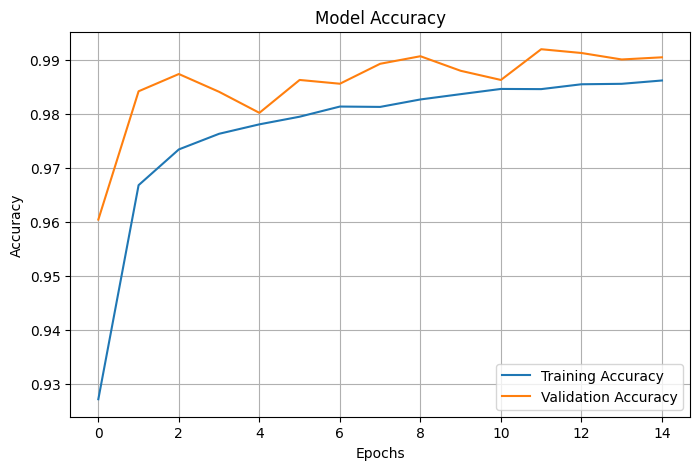

In [13]:
# Training Accuracy
plt.figure(figsize=(8,5))
plt.plot(trainingHistory.history['accuracy'],label='Training Accuracy')
plt.plot(trainingHistory.history['val_accuracy'],label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Loss Graph Of The Model

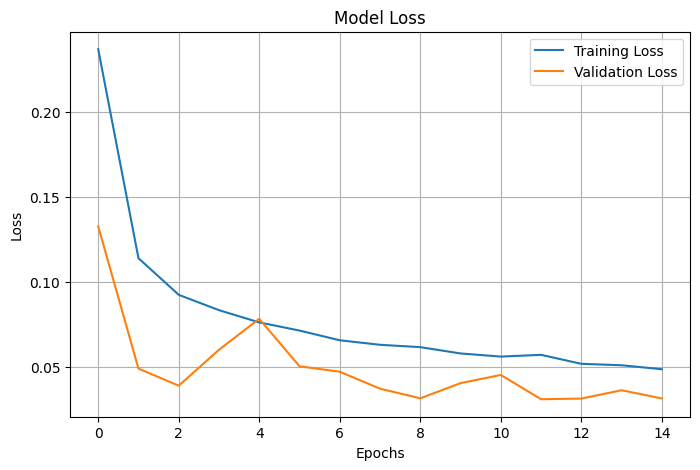

In [14]:
# Training Loss
plt.figure(figsize=(8,5))
plt.plot(trainingHistory.history['loss'],label='Training Loss')
plt.plot(trainingHistory.history['val_loss'],label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix Cell Of The Model

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


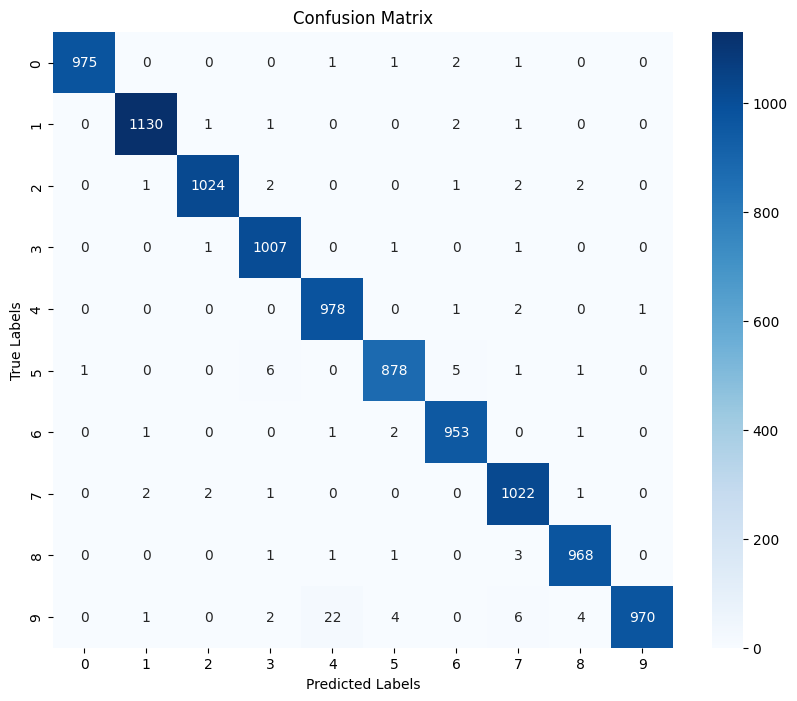

In [15]:
# Predictions on test data
predictions=digitModel.predict(testImages)
predictedLabels=np.argmax(predictions,axis=1)

# Confusion matrix
confusionMatrix=confusion_matrix(testLabels,predictedLabels)

# Plotting
plt.figure(figsize=(10,8))
sns.heatmap(confusionMatrix,annot=True,
fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

Visuals Prediction Cell In Accordance To The Model

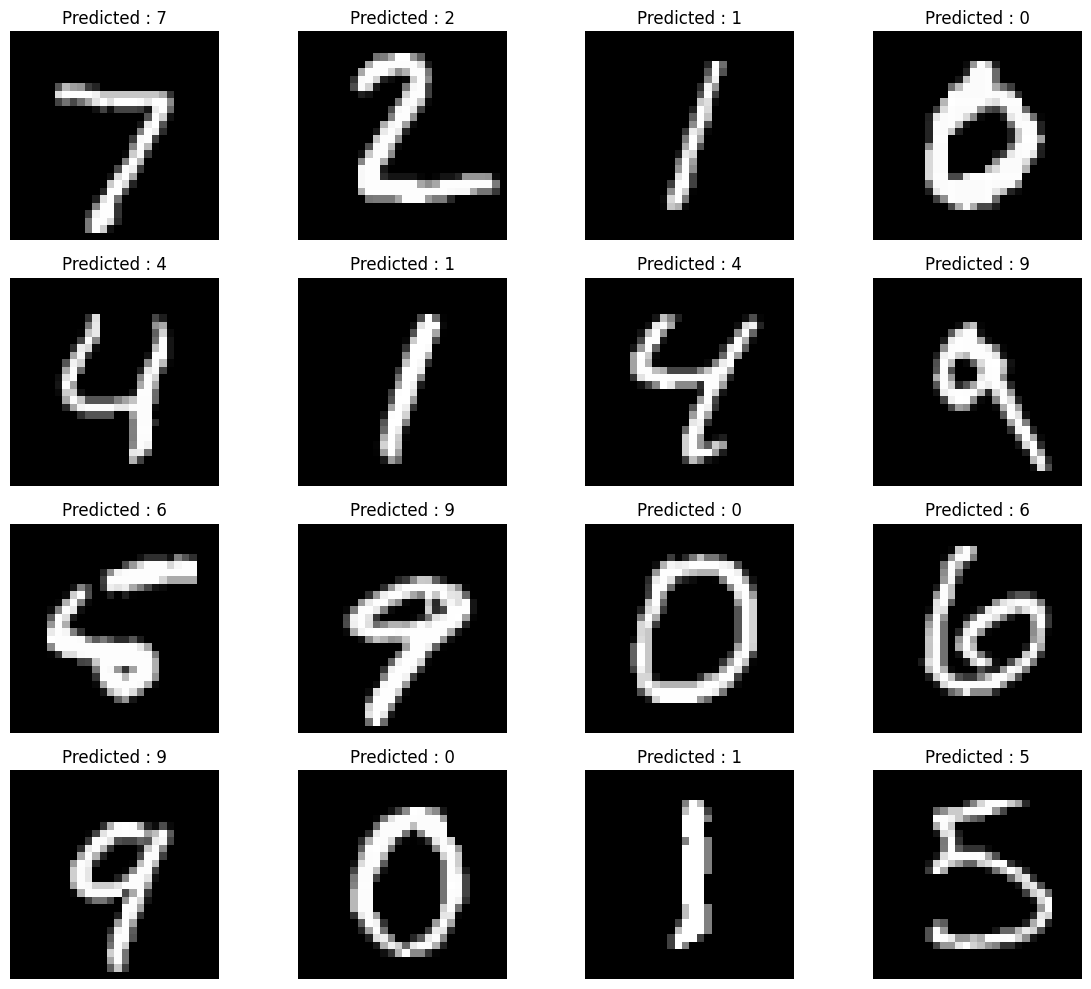

In [16]:
# Showing sample predictions

plt.figure(figsize=(12,10))
for index in range(16):
    plt.subplot(4,4,index+1)
    plt.imshow(testImages[index].reshape(28,28),cmap='gray')
    prediction=np.argmax(
        digitModel.predict(
            testImages[index].reshape(1,28,28,1),
            verbose=0
        )
    )
    plt.title(f"Predicted : {prediction}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Confidence Visualization Of The Model

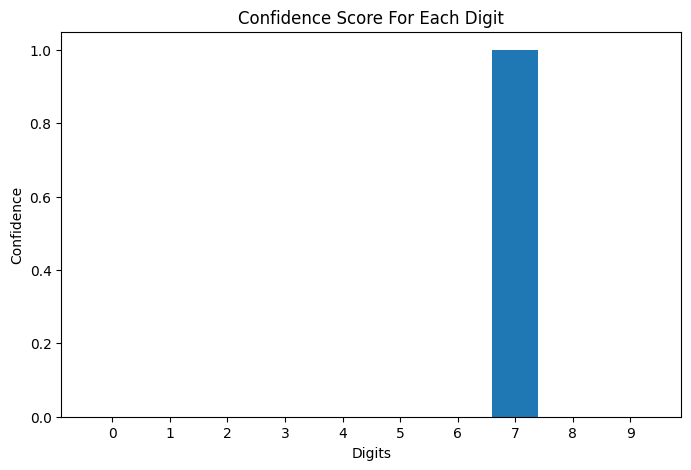

In [17]:
# Predicting one sample

sampleImage=testImages[0]
prediction=digitModel.predict(
    sampleImage.reshape(1,28,28,1),
    verbose=0
)

# Plotting confidence
plt.figure(figsize=(8,5))
plt.bar(range(10),prediction[0])
plt.title("Confidence Score For Each Digit")
plt.xlabel("Digits")
plt.ylabel("Confidence")
plt.xticks(range(10))
plt.show()

Final Model Evaluation Cell

In [18]:
# Final evaluation

testLoss,testAccuracy=digitModel.evaluate(
    testImages,
    testLabels,
    verbose=0
)
print(f"Final Test Accuracy : {testAccuracy*100:.2f}%")
print(f"Final Test Loss : {testLoss:.4f}")

Final Test Accuracy : 99.05%
Final Test Loss : 0.0317


Web Application Support

- Acts as the backend server for the web application using Flask.
- Handles image upload functionality from the user interface.
- Sends uploaded images for prediction and displays the detected digits.

In [19]:
# FLASK APP
app=Flask(__name__)
uploadFolder="Static/Uploads"
app.config['UPLOAD_FOLDER']=uploadFolder

# Creating upload folder if not exists
os.makedirs(uploadFolder,exist_ok=True)

# HOME PAGE
@app.route("/",methods=["GET","POST"])

def homePage():
    detectedOutput=None
    uploadedImagePath=None
    detectedType=None
    ocrDetectedText=None
    if request.method=="POST":
        uploadedFile=request.files["file"]

        # No file selected
        if uploadedFile.filename=="":
            return "No File Selected"
        
        if uploadedFile:
            
            # Save image
            savedPath=os.path.join(app.config['UPLOAD_FOLDER'],uploadedFile.filename)
            uploadedFile.save(savedPath)
            
            # Fix Windows path
            uploadedImagePath=uploadedFile.filename

            # OCR CHECK
            extractedText=performOCR(savedPath)
            ocrDetectedText=extractedText
            
            # ROMAN NUMERAL DETECTION
            if (extractedText is not None and isRomanNumeral(extractedText)):
                detectedOutput=romanToInteger(extractedText)
                detectedType="Roman Numeral"
                
            # HANDWRITTEN DIGIT DETECTION
            else:
                detectedOutput=predictDigits(savedPath)
                detectedType=("Handwritten Digits")
                
    return render_template(
        "index.html",
        prediction=detectedOutput,
        image_path=uploadedImagePath,
        detected_type=detectedType
    )

# RUN APPLICATION
app.run(debug=True,use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: on
Digit 1 Detected As 8 With 100.00% Confidence
Digit 2 Detected As 8 With 100.00% Confidence
Digit 3 Detected As 0 With 100.00% Confidence
Digit 4 Detected As 6 With 99.97% Confidence

Final Detected Number : 8806


Submitted By-

Group 12 Members-

- Amulya Shrivastava, 2341019456
- Amaan Ahmed, 2341001055
- Anusha Kumari, 2341011265
- Kumari Muskan, 2341013427